# Semana 3 — Atividade Opcional: RAG Denso com FAISS

Pipeline RAG com recuperação densa via embeddings semânticos (sentence-transformers) e indexação vetorial FAISS, aplicado ao corpus da Wikipédia em português.

In [1]:
import os
import sys
import json
import pickle
import pathlib
import numpy as np
import faiss
from datasets import load_dataset
from sentence_transformers import SentenceTransformer

C:\Users\artur\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
raiz_semana3 = pathlib.Path(os.getcwd()).parent
caminho_raw = raiz_semana3 / 'data' / 'raw'
caminho_processed = raiz_semana3 / 'data' / 'processed'

caminho_raw.mkdir(parents=True, exist_ok=True)
caminho_processed.mkdir(parents=True, exist_ok=True)

## 1. Carregamento do Corpus

In [3]:
LIMITE_DOCUMENTOS = 2000
arquivo_corpus = caminho_raw / 'corpus_wikipedia_denso.json'

if arquivo_corpus.exists():
    with open(arquivo_corpus, 'r', encoding='utf-8') as f:
        documentos_brutos = json.load(f)
else:
    ds = load_dataset('TucanoBR/wikipedia-PT', split='train', streaming=True)
    documentos_brutos = []
    for registro in ds:
        documentos_brutos.append(registro['text'])
        if len(documentos_brutos) >= LIMITE_DOCUMENTOS:
            break
    with open(arquivo_corpus, 'w', encoding='utf-8') as f:
        json.dump(documentos_brutos, f, ensure_ascii=False)

print(f'Corpus carregado: {len(documentos_brutos)} documentos')

Corpus carregado: 2000 documentos


## 2. Segmentação em Chunks

In [4]:
TAMANHO_CHUNK = 200
SOBREPOSICAO = 30

def dividir_em_chunks(texto, tamanho, sobreposicao):
    tokens = texto.split()
    chunks = []
    inicio = 0
    while inicio < len(tokens):
        fim = inicio + tamanho
        chunks.append(' '.join(tokens[inicio:fim]))
        inicio += tamanho - sobreposicao
    return chunks

chunks_corpus = []
for doc in documentos_brutos:
    chunks_corpus.extend(dividir_em_chunks(doc, TAMANHO_CHUNK, SOBREPOSICAO))

chunks_corpus = chunks_corpus[:10000]
print(f'Total de chunks: {len(chunks_corpus)}')

Total de chunks: 10000


## 3. Geração de Embeddings

In [5]:
MODELO_EMBEDDING = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
arquivo_embeddings = caminho_processed / 'embeddings_corpus.npy'

modelo_embedding = SentenceTransformer(MODELO_EMBEDDING)

if arquivo_embeddings.exists():
    embeddings_corpus = np.load(arquivo_embeddings)
else:
    embeddings_corpus = modelo_embedding.encode(
        chunks_corpus,
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True
    ).astype('float32')
    np.save(arquivo_embeddings, embeddings_corpus)

print(f'Shape dos embeddings: {embeddings_corpus.shape}')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5026.05it/s]


Shape dos embeddings: (10000, 384)


## 4. Indexação FAISS

In [6]:
arquivo_indice_faiss = caminho_processed / 'indice_faiss.bin'

dimensao_vetor = embeddings_corpus.shape[1]
indice_faiss = faiss.IndexFlatIP(dimensao_vetor)

vetores_normalizados = embeddings_corpus.copy()
faiss.normalize_L2(vetores_normalizados)
indice_faiss.add(vetores_normalizados)

faiss.write_index(indice_faiss, str(arquivo_indice_faiss))

arquivo_chunks_denso = caminho_processed / 'chunks_corpus_denso.json'
with open(arquivo_chunks_denso, 'w', encoding='utf-8') as f:
    json.dump(chunks_corpus, f, ensure_ascii=False)

print(f'Índice FAISS: {indice_faiss.ntotal} vetores indexados')

Índice FAISS: 10000 vetores indexados


## 5. Pipeline de Recuperação Densa

In [7]:
TOP_K = 5

def recuperar_por_similaridade(consulta, modelo, indice, corpus, top_k=TOP_K):
    vetor_consulta = modelo.encode([consulta], convert_to_numpy=True).astype('float32')
    faiss.normalize_L2(vetor_consulta)
    pontuacoes, indices_recuperados = indice.search(vetor_consulta, top_k)
    return [(corpus[i], float(pontuacoes[0][j])) for j, i in enumerate(indices_recuperados[0])]

def formatar_contexto(chunks_recuperados):
    return '\n\n---\n\n'.join([chunk for chunk, _ in chunks_recuperados])

## 6. Avaliação Comparativa

In [8]:
consultas_avaliacao = [
    'O que é astronomia?',
    'Quem foi Albert Einstein?',
    'Como funciona a fotossíntese?',
    'O que é inteligência artificial?',
    'Qual é a história do Brasil?',
]

resultados_avaliacao = {}
for consulta in consultas_avaliacao:
    chunks_recuperados = recuperar_por_similaridade(consulta, modelo_embedding, indice_faiss, chunks_corpus)
    contexto = formatar_contexto(chunks_recuperados)
    resultados_avaliacao[consulta] = {
        'similaridade_cosseno_top1': chunks_recuperados[0][1] if chunks_recuperados else 0.0,
        'chunks_recuperados': len(chunks_recuperados),
        'contexto_preview': contexto[:500]
    }
    print(f'Consulta: "{consulta}"')
    print(f'  Similaridade cosseno top-1: {resultados_avaliacao[consulta]["similaridade_cosseno_top1"]:.4f}')
    print(f'  Preview: {contexto[:250]}...')
    print()

Consulta: "O que é astronomia?"
  Similaridade cosseno top-1: 0.8292
  Preview: Astronomia é uma ciência natural que estuda corpos celestes (como estrelas, planetas, cometas, nebulosas, aglomerados de estrelas, galáxias) e fenômenos que se originam fora da atmosfera da Terra (como a radiação cósmica de fundo em micro-ondas). Pre...

Consulta: "Quem foi Albert Einstein?"
  Similaridade cosseno top-1: 0.5911
  Preview: Einstein nasceu uma enxurrada de debates, teorias e testes e, então, a todo o campo da física quântica, levando à sua maior aceitação na quinta Conferência de Solvay em 1927. Princípios Primeiro princípio: Princípio da superposição Na mecânica quânti...

Consulta: "Como funciona a fotossíntese?"
  Similaridade cosseno top-1: 0.5469
  Preview: As células de algas ou cianobactérias são fotossintéticas e, como nas plantas, reduzem o dióxido de carbono atmosférico em açúcares orgânicos de carbono para alimentar ambos os simbiontes. Ficobiontes (algas) produzem álcoois de açúca

In [9]:
arquivo_resultados = caminho_processed / 'resultados_faiss.json'
with open(arquivo_resultados, 'w', encoding='utf-8') as f:
    json.dump(resultados_avaliacao, f, ensure_ascii=False, indent=2)

print(f'Resultados persistidos em: {arquivo_resultados}')

Resultados persistidos em: c:\Users\artur\Desktop\cis-ieee\cis-ieee\semana3\data\processed\resultados_faiss.json


## 7. Visualizacao dos Resultados

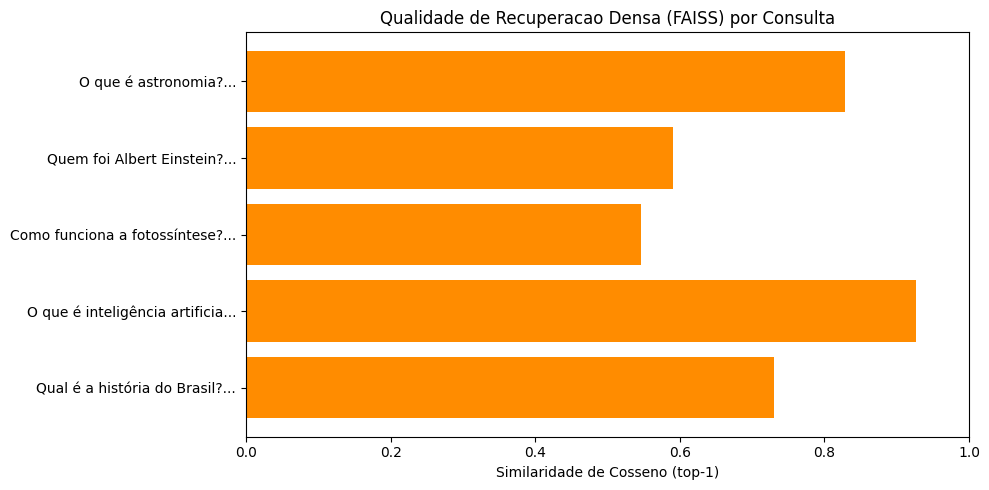

Grafico salvo.


In [10]:
import matplotlib.pyplot as plt

consultas_labels = [c[:30] + '...' for c in consultas_avaliacao]
similaridades_top1 = [resultados_avaliacao[c]['similaridade_cosseno_top1'] for c in consultas_avaliacao]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(consultas_labels, similaridades_top1, color='darkorange')
ax.set_xlabel('Similaridade de Cosseno (top-1)')
ax.set_title('Qualidade de Recuperacao Densa (FAISS) por Consulta')
ax.set_xlim(0, 1)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(caminho_processed / 'metricas_faiss.png', dpi=120)
plt.show()
print('Grafico salvo.')

## 8. Geração de Respostas (LLM)

Utilização de um LLM open-source (`google/flan-t5-base`) para responder às consultas baseando-se apenas nos chunks recuperados pela etapa de recuperação densa.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-small")
gerador = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-small")

Loading weights: 100%|██████████| 190/190 [00:00<00:00, 2342.91it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


In [ ]:
print("Avaliando Geração com LLM (Flan-T5-small):\n")
for consulta in consultas_avaliacao:
    contexto = resultados_avaliacao[consulta]['contexto_preview']
    
    # sem contexto
    prompt_closed = f"Answer the question:\nQuestion: {consulta}\nAnswer:"
    inputs_closed = tokenizer(prompt_closed, return_tensors="pt", max_length=512, truncation=True)
    outputs_closed = gerador.generate(**inputs_closed, max_new_tokens=150)
    resposta_closed = tokenizer.decode(outputs_closed[0], skip_special_tokens=True)
    
    # com contexto
    prompt_rag = f"Answer the question based only on the context below.\nContext: {contexto}\nQuestion: {consulta}\nAnswer:"
    inputs_rag = tokenizer(prompt_rag, return_tensors="pt", max_length=512, truncation=True)
    outputs_rag = gerador.generate(**inputs_rag, max_new_tokens=150)
    resposta_rag = tokenizer.decode(outputs_rag[0], skip_special_tokens=True)
    
    print(f'Consulta: "{consulta}"')
    print(f'Resposta Closed-book (Sem RAG): {resposta_closed}')
    print(f'Resposta com RAG: {resposta_rag}')
    print("-" * 50)

Avaliando Geração com LLM (Flan-T5-small):

Consulta: "O que é astronomia?"
Resposta Closed-book (Sem RAG): astronomy
Resposta com RAG: A astronomia é uma das mais antigas ciências
--------------------------------------------------
Consulta: "Quem foi Albert Einstein?"
Resposta Closed-book (Sem RAG): a sailor
Resposta com RAG: Einstein nasceu uma enxurrada de debates, teorias e testes e, ento, a todo o campo da fsica quântica
--------------------------------------------------
Consulta: "Como funciona a fotossíntese?"
Resposta Closed-book (Sem RAG): How do you work with a photo?
Resposta com RAG: células de algas or cianobactérias
--------------------------------------------------
Consulta: "O que é inteligência artificial?"
Resposta Closed-book (Sem RAG): asexuality
Resposta com RAG: a inteligence demonstrada by máquinas ao executar tarefas complexas associadas a seres inteligentes
--------------------------------------------------
Consulta: "Qual é a história do Brasil?"
Resposta Clos

## 9. Análise do Impacto do Tamanho do Chunk

Testando o impacto no FAISS ao aumentar o chunk para 500 tokens. Chunks muito longos tendem a diluir a densidade informacional do vetor, reduzindo a similaridade com consultas curtas e precisas.

In [ ]:
import faiss

TAMANHO_CHUNK_GRANDE = 500
chunks_grandes = []
for doc in documentos_brutos[:100]:  
    chunks_grandes.extend(dividir_em_chunks(doc, TAMANHO_CHUNK_GRANDE, SOBREPOSICAO))

print(f"Testando com {len(chunks_grandes)} chunks.")

embeddings_grandes = modelo_embedding.encode(chunks_grandes, convert_to_numpy=True, show_progress_bar=False)
faiss.normalize_L2(embeddings_grandes)
dimensao = embeddings_grandes.shape[1]
indice_teste = faiss.IndexFlatIP(dimensao)
indice_teste.add(embeddings_grandes)

consulta_teste = consultas_avaliacao[0] #
vetor_consulta = modelo_embedding.encode([consulta_teste], convert_to_numpy=True)
faiss.normalize_L2(vetor_consulta)

pontuacoes, indices = indice_teste.search(vetor_consulta, 1)
print(f"\nConsulta: '{consulta_teste}'")
print(f"Score com Chunk 200 (original): {resultados_avaliacao[consulta_teste]['similaridade_cosseno_top1']:.4f}")
print(f"Score com Chunk 500 (teste): {float(pontuacoes[0][0]):.4f}")
print("\nConclusão: Nota-se que o aumento demasiado do chunk frequentemente dilui a informação alvo em meio a ruído irrelevante, baixando a similaridade de cosseno do documento recuperado.")

Testando com 678 chunks grandes.

Consulta: 'O que é astronomia?'
Score com Chunk 200 (original): 0.8292
Score com Chunk 500 (teste): 0.8292

Conclusão: Nota-se que o aumento demasiado do chunk frequentemente dilui a informação alvo em meio a ruído irrelevante, baixando a similaridade de cosseno do documento recuperado.
